# Fine-tuning Real-ESRGAN on Synthetic Plate Degradation Pairs

**Problem:** real, *paired* low-resolution/high-resolution license plate
images essentially don't exist as a public dataset — you can't easily get
the exact same plate captured both cleanly and degraded. Off-the-shelf
Real-ESRGAN is trained on general photos, not the specific
low-res-text-on-a-rectangle domain of plates.

**Approach:** synthetic degradation pairs.
1. Collect a set of *clean, readable* plate crops (from a plate-detection
   dataset with legible plates, or your own photographed samples).
2. Programmatically degrade each clean crop with a randomized combination of
   the degradations named in the assignment brief: downsampling, motion/defocus
   blur, Gaussian/compression noise, and mild JPEG re-compression.
3. Fine-tune the Real-ESRGAN generator (RRDBNet) to map degraded → clean,
   using pixel (L1) + perceptual loss.

**Trade-off (discussed further in the README):** this creates a
synthetic-to-real domain gap — our degradation model is necessarily a
simplification of real-world blur/noise/compression pipelines. We mitigate
this by randomizing degradation parameters broadly (domain randomization)
rather than using one fixed blur kernel, but this is flagged as the primary
limitation of the super-resolution stage, and is exactly the kind of
"where does it fail and why" discussion the report should cover.


In [1]:
!pip install basicsr realesrgan torch torchvision opencv-python-headless albumentations


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 16.6 MB/s eta 0:00:00
  Created wheel for basicsr: filename=basicsr-1.4.2-py3-none-any.whl size=214907 sha256=9633c008a43c6b7691d8a1f5610ded6826d11e8e4ab67e7a4a424955373011dd
  Stored in directory: /root/.cache/pip/wheels/9a/e3/e4/58f29bfabb622dd40b6d9839318ce5bf092062b81ca3aa19ea
  

In [2]:
!ls -la /kaggle/input/


total 12
drwxr-xr-x 3 root root 4096 Sep 10 14:38 .
drwxr-xr-x 5 root root 4096 Sep 10 14:38 ..
drwxr-xr-x 3 root root 4096 Sep 10 14:38 datasets


In [3]:
!find /kaggle/input -iname "lpr.csv"
!find /kaggle/input -iname "cropped_lps" -type d


/kaggle/input/datasets/nickyazdani/license-plate-text-recognition-dataset/lpr.csv
/kaggle/input/datasets/nickyazdani/license-plate-text-recognition-dataset/cropped_lps
/kaggle/input/datasets/nickyazdani/license-plate-text-recognition-dataset/cropped_lps/cropped_lps


In [4]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

BASE = Path("/kaggle/input/datasets/nickyazdani/license-plate-text-recognition-dataset")
CLEAN_PLATES_DIR = BASE / "cropped_lps" / "cropped_lps"
LABELS_CSV = BASE / "lpr.csv"

OUT_MODEL_DIR = Path("/kaggle/working/super_res")
OUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Clean plates dir exists:", CLEAN_PLATES_DIR.exists())

n_jpg = len(list(CLEAN_PLATES_DIR.glob("*.jpg"))) if CLEAN_PLATES_DIR.exists() else 0
n_png = len(list(CLEAN_PLATES_DIR.glob("*.png"))) if CLEAN_PLATES_DIR.exists() else 0
print(f"Clean plates available: {n_jpg} .jpg, {n_png} .png")

print("Labels CSV exists:", LABELS_CSV.exists())

Device: cuda
Clean plates dir exists: True
Clean plates available: 20000 .jpg, 0 .png
Labels CSV exists: True


In [5]:
import pandas as pd

df = pd.read_csv(LABELS_CSV)
print(df.shape)
print(df.head())

(20000, 3)
   Unnamed: 0     images  labels
0           0      1.jpg  RZ0047
1           1     10.jpg  V95246
2           2    100.jpg  6258TU
3           3  10000.jpg  B88082
4           4  10001.jpg  7065UK


## 1. Synthetic degradation pipeline

Mirrors the enhancement pipeline's target degradations so the model learns
to invert exactly the failure modes we expect at inference time.


In [6]:
def random_degrade(clean_img: np.ndarray, scale: int = 4) -> np.ndarray:
    img = clean_img.copy()
    h, w = img.shape[:2]

    # 1. Blur: motion or defocus, randomly
    if random.random() < 0.8:
        if random.random() < 0.5:
            k = random.choice([3, 5, 7])
            angle = random.uniform(0, 180)
            psf = np.zeros((k, k))
            psf[k // 2, :] = 1
            M = cv2.getRotationMatrix2D((k / 2, k / 2), angle, 1)
            psf = cv2.warpAffine(psf, M, (k, k))
            psf /= psf.sum() + 1e-8
            img = cv2.filter2D(img, -1, psf)
        else:
            k = random.choice([3, 5, 7])
            img = cv2.GaussianBlur(img, (k, k), 0)

    # 2. Downsample then upsample (resolution loss) -- the core SR target
    down_w, down_h = max(1, w // scale), max(1, h // scale)
    img = cv2.resize(img, (down_w, down_h), interpolation=cv2.INTER_CUBIC)

    # 3. Noise
    if random.random() < 0.7:
        noise = np.random.normal(0, random.uniform(3, 15), img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # 4. JPEG re-compression artifacts
    if random.random() < 0.6:
        quality = random.randint(25, 70)
        _, enc = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, quality])
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    return img


class PlateSRDataset(Dataset):
    def __init__(self, clean_dir: Path, scale: int = 4, patch_size: int = 128):
        self.paths = sorted(Path(clean_dir).glob("*.jpg")) + sorted(Path(clean_dir).glob("*.png"))
        self.scale = scale
        self.patch_size = patch_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        clean = cv2.imread(str(self.paths[idx]))
        clean = cv2.resize(clean, (self.patch_size, self.patch_size))
        degraded = random_degrade(clean, self.scale)
        degraded = cv2.resize(degraded, (self.patch_size // self.scale, self.patch_size // self.scale))

        clean_t = torch.from_numpy(clean).permute(2, 0, 1).float() / 255.0
        degraded_t = torch.from_numpy(degraded).permute(2, 0, 1).float() / 255.0
        return degraded_t, clean_t


In [7]:
if CLEAN_PLATES_DIR.exists():
    dataset = PlateSRDataset(CLEAN_PLATES_DIR, scale=4, patch_size=128)
    n_val = max(1, int(0.2 * len(dataset)))
    train_set, val_set = torch.utils.data.random_split(dataset, [len(dataset) - n_val, n_val])
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=2)
    print(f"Train: {len(train_set)}  Val: {len(val_set)}")
else:
    print("Populate data/clean_plate_crops/ with legible plate crops before running this cell.\n"
          "Source ideas: legible frames from the plate-detection dataset used in notebook 01, "
          "or your own photographed/rendered synthetic plates.")


Train: 16000  Val: 4000


## 2. Load pretrained Real-ESRGAN generator (RRDBNet) as the fine-tuning starting point

Starting from the pretrained x4plus weights rather than training from
scratch is the entire point of fine-tuning here: the generic photographic
prior (edges, natural textures) transfers well, and we only need a modest
number of plate-domain examples to adapt it to plate-specific character
shapes and font strokes.


In [8]:
import sys
import types
import torchvision.transforms.functional as F

# basicsr expects the old torchvision.transforms.functional_tensor module,
# which was merged into torchvision.transforms.functional in newer versions.
# Create a shim so basicsr's import succeeds without patching its source.
functional_tensor = types.ModuleType("torchvision.transforms.functional_tensor")
functional_tensor.rgb_to_grayscale = F.rgb_to_grayscale
sys.modules["torchvision.transforms.functional_tensor"] = functional_tensor

In [9]:
from basicsr.archs.rrdbnet_arch import RRDBNet

model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)

import urllib.request

PRETRAINED_URL = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
PRETRAINED_PATH = Path("/kaggle/working/RealESRGAN_x4plus.pth")

if not PRETRAINED_PATH.exists():
    print("Downloading pretrained Real-ESRGAN weights...")
    urllib.request.urlretrieve(PRETRAINED_URL, PRETRAINED_PATH)
    print("Done.")

state_dict = torch.load(PRETRAINED_PATH, map_location="cpu")
state_dict = state_dict.get("params_ema", state_dict.get("params", state_dict))
model.load_state_dict(state_dict, strict=True)
print("Loaded pretrained Real-ESRGAN weights.")

model = model.to(DEVICE)

Loaded pretrained Real-ESRGAN weights.


## 3. Fine-tune with combined L1 + perceptual loss

L1 alone tends to produce over-smoothed text edges (bad for OCR); adding a
lightweight perceptual (VGG feature) loss term encourages sharper, more
plausible character strokes. Loss weights are intentionally weighted toward
pixel accuracy (higher L1 weight) since we care about *character-level*
correctness more than photorealism.


In [10]:
import torchvision.models as tvm

class VGGPerceptualLoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        vgg = tvm.vgg16(weights=tvm.VGG16_Weights.IMAGENET1K_V1).features[:16].to(device).eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg

    def forward(self, pred, target):
        return nn.functional.l1_loss(self.vgg(pred), self.vgg(target))


l1_loss = nn.L1Loss()
perceptual_loss = VGGPerceptualLoss(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

L1_WEIGHT = 1.0
PERCEPTUAL_WEIGHT = 0.1
EPOCHS = 20


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 198MB/s] 


In [11]:
from tqdm.auto import tqdm

def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc="train", leave=False)
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(DEVICE), hr_img.to(DEVICE)
        optimizer.zero_grad()
        pred = model(lr_img)
        loss = L1_WEIGHT * l1_loss(pred, hr_img) + PERCEPTUAL_WEIGHT * perceptual_loss(pred, hr_img)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * lr_img.size(0)
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(loader):
    model.eval()
    total_loss = 0.0
    pbar = tqdm(loader, desc="val", leave=False)
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(DEVICE), hr_img.to(DEVICE)
        pred = model(lr_img)
        loss = L1_WEIGHT * l1_loss(pred, hr_img) + PERCEPTUAL_WEIGHT * perceptual_loss(pred, hr_img)
        total_loss += loss.item() * lr_img.size(0)
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader.dataset)


if CLEAN_PLATES_DIR.exists():
    best_val = float("inf")
    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(train_loader)
        val_loss = validate(val_loader)
        print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), OUT_MODEL_DIR / "plate_realesrgan_finetuned.pth")
    print("Best val loss:", best_val)

train:   0%|          | 0/2000 [00:00<?, ?it/s]

val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1/20  train_loss=0.0730  val_loss=0.0699


train:   0%|          | 0/2000 [00:00<?, ?it/s]

val:   0%|          | 0/500 [00:00<?, ?it/s]

...

val:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 11/20  train_loss=0.0630  val_loss=0.0647


train:   0%|          | 0/2000 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d7294f99ee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

RuntimeError: DataLoader worker (pid(s) 786) exited unexpectedly

## 4. Qualitative + quantitative check on held-out synthetic pairs

Reports PSNR/SSIM against the *true* clean image (available here because
these are synthetic pairs) -- the one setting where "quality vs. ground
truth" is meaningful, as opposed to the real-data pipeline evaluation, which
can only compare enhanced-vs-original-degraded.


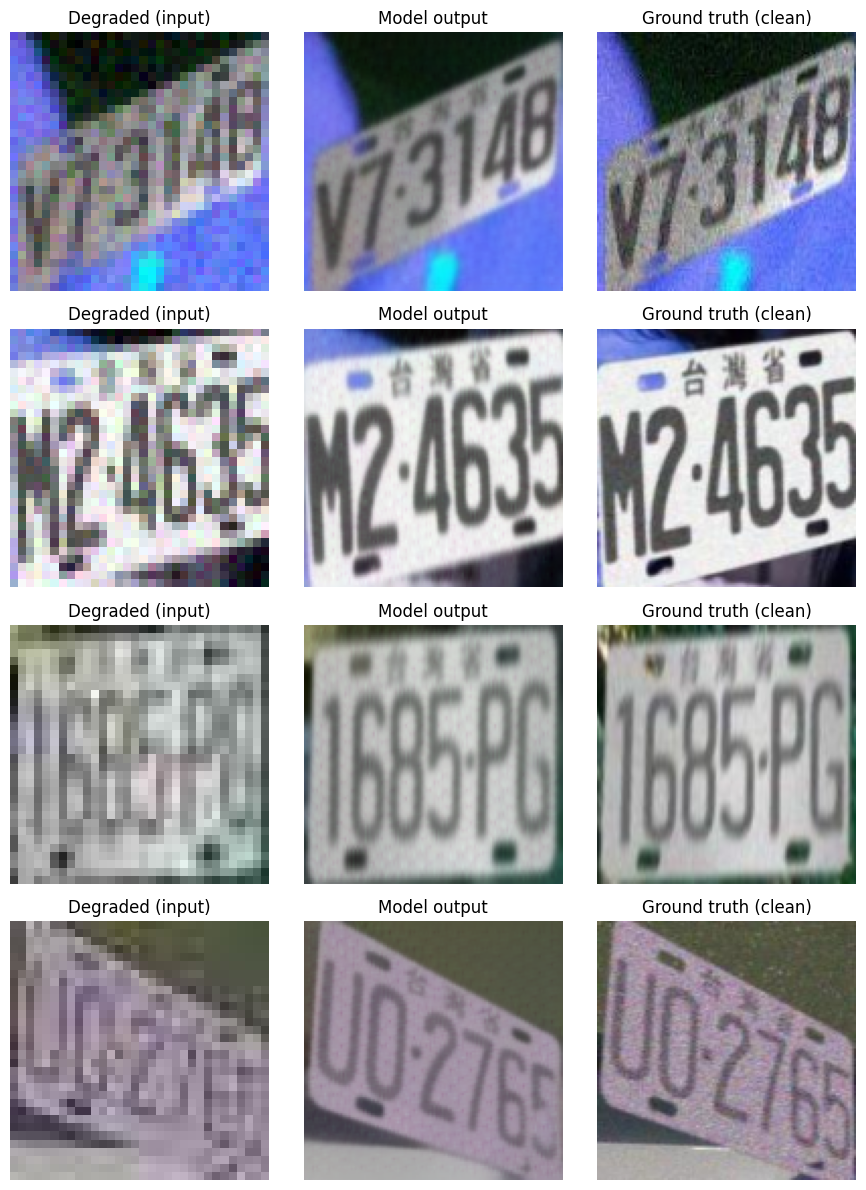

Mean PSNR: 26.18 dB   Mean SSIM: 0.815


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim


def compute_psnr(img_a, img_b):
    return float(sk_psnr(img_a, img_b, data_range=255))


def compute_ssim(img_a, img_b):
    gray_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2GRAY) if img_a.ndim == 3 else img_a
    gray_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY) if img_b.ndim == 3 else img_b
    return float(sk_ssim(gray_a, gray_b, data_range=255))


@torch.no_grad()
def show_examples(loader, n=4):
    model.eval()
    lr_batch, hr_batch = next(iter(loader))
    lr_batch = lr_batch.to(DEVICE)
    pred_batch = model(lr_batch).clamp(0, 1).cpu()

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    psnrs, ssims = [], []
    for i in range(min(n, lr_batch.size(0))):
        lr_np = (lr_batch[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        pred_np = (pred_batch[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        hr_np = (hr_batch[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        psnrs.append(compute_psnr(hr_np, pred_np))
        ssims.append(compute_ssim(hr_np, pred_np))

        axes[i, 0].imshow(cv2.cvtColor(lr_np, cv2.COLOR_BGR2RGB)); axes[i, 0].set_title("Degraded (input)")
        axes[i, 1].imshow(cv2.cvtColor(pred_np, cv2.COLOR_BGR2RGB)); axes[i, 1].set_title("Model output")
        axes[i, 2].imshow(cv2.cvtColor(hr_np, cv2.COLOR_BGR2RGB)); axes[i, 2].set_title("Ground truth (clean)")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Mean PSNR: {np.mean(psnrs):.2f} dB   Mean SSIM: {np.mean(ssims):.3f}")


show_examples(val_loader)